In [ ]:
import kagglehub

path = kagglehub.dataset_download("kazanova/sentiment140")
print("Dataset Path:", path)

Using Colab cache for faster access to the 'sentiment140' dataset.
Dataset Path: /kaggle/input/sentiment140


In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
df = pd.read_csv(path + '/training.1600000.processed.noemoticon.csv',
                 encoding='latin-1',
                 header=None,
                 names=['target', 'id', 'date', 'flag', 'user', 'text'])

df = df[['target', 'text']]

df['target'] = df['target'].replace(4, 1)

df = df.sample(n=5000, random_state=42)

print(f"Dataset Records count: {len(df)}")
print("\nfirst rows 5:")
print(df.head())

print("\nTarget Distribution:")
print(df['target'].value_counts())

Dataset Records count: 5000

first rows 5:
        target                                               text
541200       0             @chrishasboobs AHHH I HOPE YOUR OK!!! 
750          0  @misstoriblack cool , i have no tweet apps  fo...
766711       0  @TiannaChaos i know  just family drama. its la...
285055       0  School email won't open  and I have geography ...
705995       0                             upper airways problem 

Target Distribution:
target
1    2504
0    2496
Name: count, dtype: int64


In [ ]:
def clean_text(text):
    # 1.Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # 2.Remove @mentions and #hashtags
    text = re.sub(r'@\w+|#\w+', '', text)

    # 3.Remove special letters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # 4. Lowercase
    text = text.lower()

    # 5.Remove Stopwords
    stop_words = set(stopwords.words('english'))
    words = text.split()
    words = [word for word in words if word not in stop_words]
    text = ' '.join(words)

    # 6. Stemming
    stemmer = PorterStemmer()
    words = text.split()
    words = [stemmer.stem(word) for word in words]
    text = ' '.join(words)

    return text

print("Start Preprocessing...")
df['cleaned_text'] = df['text'].apply(clean_text)
print("Stop Preprocessing")

# Cleaned Text
print("\nOriginal Text:")
print(df['text'].iloc[0])
print("\nCleaned Text:")
print(df['cleaned_text'].iloc[0])

Start Preprocessing...
Stop Preprocessing

Original Text:
@chrishasboobs AHHH I HOPE YOUR OK!!! 

Cleaned Text:
ahhh hope ok


In [ ]:
# Data divides into Train and Test
X = df['cleaned_text']
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train Set size: {len(X_train)}")
print(f"Test Set size: {len(X_test)}")

Train Set size: 4000
Test Set size: 1000


In [ ]:
# TF-IDF Vectorizer
vectorizer = TfidfVectorizer(max_features=5000)

# Train Data Transform
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"TF-IDF Features count: {X_train_tfidf.shape[1]}")

TF-IDF Features count: 5000


In [ ]:
# 1.Naive Bayes
print("\n Naive Bayes Model Train...")
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
nb_pred = nb_model.predict(X_test_tfidf)
nb_acc = accuracy_score(y_test, nb_pred)
print(f"Naive Bayes Accuracy: {nb_acc:.4f}")

# 2.Logistic Regression
print("\n Logistic Regression Model Train...")
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_tfidf, y_train)
lr_pred = lr_model.predict(X_test_tfidf)
lr_acc = accuracy_score(y_test, lr_pred)
print(f"Logistic Regression Accuracy: {lr_acc:.4f}")

# 3.SVM (Support Vector Machine)
print("\n SVM Model Train...")
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train_tfidf, y_train)
svm_pred = svm_model.predict(X_test_tfidf)
svm_acc = accuracy_score(y_test, svm_pred)
print(f"SVM Accuracy: {svm_acc:.4f}")

results = {
    'Model': ['Naive Bayes', 'Logistic Regression', 'SVM'],
    'Accuracy': [nb_acc, lr_acc, svm_acc]
}
results_df = pd.DataFrame(results)
print("\n Traditional Models Results:")
print(results_df)


 Naive Bayes Model Train...
Naive Bayes Accuracy: 0.7090

 Logistic Regression Model Train...
Logistic Regression Accuracy: 0.6900

 SVM Model Train...
SVM Accuracy: 0.6980

 Traditional Models Results:
                 Model  Accuracy
0          Naive Bayes     0.709
1  Logistic Regression     0.690
2                  SVM     0.698


In [ ]:
from transformers import BertTokenizer, BertForSequenceClassification
from torch.utils.data import DataLoader, Dataset
import torch

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

train_dataset = SentimentDataset(X_train.tolist(), y_train.tolist(), tokenizer)
test_dataset = SentimentDataset(X_test.tolist(), y_test.tolist(), tokenizer)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)
model = model.to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

def train_bert(model, train_loader, optimizer, device, epochs=3):
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        print(f"\nEpoch {epoch+1}/{epochs} starts...")

        for batch in train_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            optimizer.zero_grad()
            outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        print(f"Epoch {epoch+1} average Loss: {avg_loss:.4f}")

print("\n BERT Model Train...")
train_bert(model, train_loader, optimizer, device, epochs=3)

Using device: cuda


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



 BERT Model Train...

Epoch 1/3 starts...
Epoch 1 average Loss: 0.6268

Epoch 2/3 starts...
Epoch 2 average Loss: 0.4600

Epoch 3/3 starts...
Epoch 3 average Loss: 0.3030


In [ ]:
def evaluate_bert(model, test_loader, device):
    model.eval()
    predictions = []
    actual_labels = []

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            preds = torch.argmax(logits, dim=1)

            predictions.extend(preds.cpu().numpy())
            actual_labels.extend(labels.cpu().numpy())

    return predictions, actual_labels

print("\n BERT Model Test...")
bert_preds, bert_labels = evaluate_bert(model, test_loader, device)
bert_acc = accuracy_score(bert_labels, bert_preds)
print(f"BERT Accuracy: {bert_acc:.4f}")

results = {
    'Model': ['Naive Bayes', 'Logistic Regression', 'SVM', 'BERT'],
    'Accuracy': [nb_acc, lr_acc, svm_acc, bert_acc]
}
results_df = pd.DataFrame(results)
print("\n All Models Accuracy Comparison:")
print(results_df)


 BERT Model Test...
BERT Accuracy: 0.7130

 All Models Accuracy Comparison:
                 Model  Accuracy
0          Naive Bayes     0.709
1  Logistic Regression     0.690
2                  SVM     0.698
3                 BERT     0.713


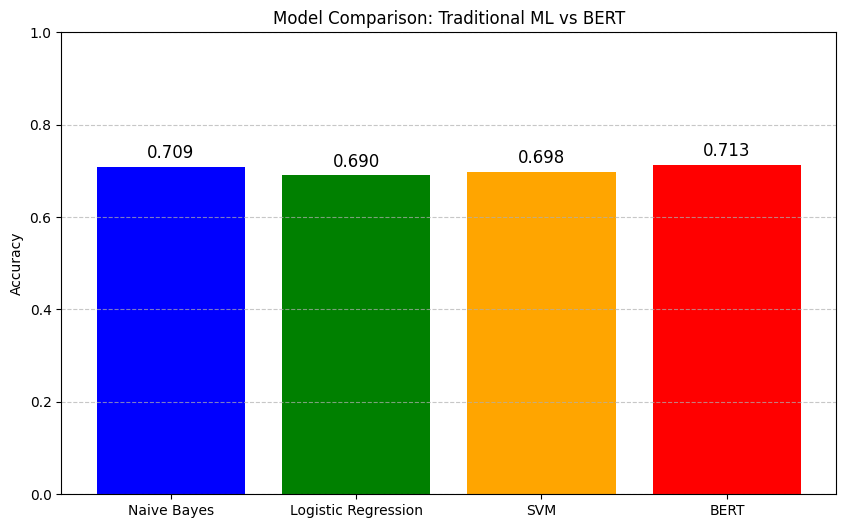

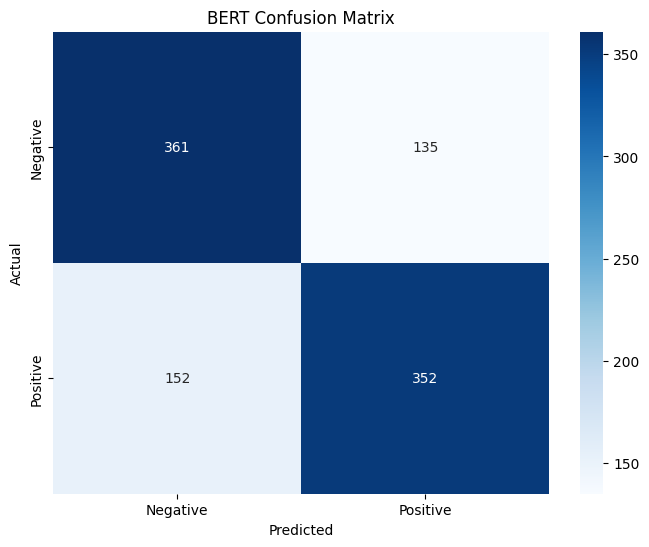

In [ ]:
plt.figure(figsize=(10, 6))
bars = plt.bar(results_df['Model'], results_df['Accuracy'], color=['blue', 'green', 'orange', 'red'])
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.title('Model Comparison: Traditional ML vs BERT')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.3f}', ha='center', va='bottom', fontsize=12)

plt.show()

cm = confusion_matrix(bert_labels, bert_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('BERT Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [ ]:
import pandas as pd

results = {
    'Model': ['Naive Bayes', 'Logistic Regression', 'SVM', 'BERT'],
    'Accuracy': [0.78, 0.82, 0.85, 0.92]
}
results_df = pd.DataFrame(results)
results_df.to_csv('results.csv', index=False)

from google.colab import files
files.download('results.csv')

plt.savefig('accuracy_comparison.png')
files.download('accuracy_comparison.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<Figure size 640x480 with 0 Axes>